# Preprocess — Steel Industry Energy Consumption

We do **not** drop features blindly. This notebook:
1. Loads the raw data
2. Checks quality & distributions
3. Checks correlations (target leakage + redundant features)
4. **Then** decides what to keep/drop based on what we see
5. Saves clean data for LSTM training

Run cells top to bottom.

## Setup & paths

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

In [ ]:
BASE = "/content/drive/MyDrive/Shared-Colab-Storage"
DATA_PATH = f"{BASE}/Steel_industry_data.csv"
SAVE_15MIN = f"{BASE}/agent-final/outputs/preprocess/15min"
SAVE_HOURLY = f"{BASE}/agent-final/outputs/preprocess/hourly"

TEST_RATIO = 0.18 

: 

In [2]:
import os
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder

os.makedirs(SAVE_15MIN, exist_ok=True)
os.makedirs(SAVE_HOURLY, exist_ok=True)

## Load raw data

In [5]:
df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
df.columns = df.columns.str.strip()
df["date"] = pd.to_datetime(df["date"], format="%d/%m/%Y %H:%M")
df = df.sort_values("date").reset_index(drop=True)

print("Shape:", df.shape)
print("Date range:", df["date"].min(), "to", df["date"].max())
print("Missing values:\n", df.isnull().sum())
print("Duplicate dates:", df["date"].duplicated().sum())

Shape: (35040, 11)
Date range: 2018-01-01 00:00:00 to 2018-12-31 23:45:00
Missing values:
 date                                    0
Usage_kWh                               0
Lagging_Current_Reactive.Power_kVarh    0
Leading_Current_Reactive_Power_kVarh    0
CO2(tCO2)                               0
Lagging_Current_Power_Factor            0
Leading_Current_Power_Factor            0
NSM                                     0
WeekStatus                              0
Day_of_week                             0
Load_Type                               0
dtype: int64
Duplicate dates: 0


In [7]:
df.head()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,2018-01-01 00:00:00,3.42,3.46,0.0,0.0,70.30,100.0,0,Weekday,Monday,Light_Load
1,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
2,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
3,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
4,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load


## Look at distributions

Before modeling we need to see if features are skewed, mostly zero, etc.

In [8]:
num_cols = [
    "Usage_kWh",
    "Lagging_Current_Reactive.Power_kVarh",
    "Leading_Current_Reactive_Power_kVarh",
    "CO2(tCO2)",
    "Lagging_Current_Power_Factor",
    "Leading_Current_Power_Factor",
    "NSM",
]

print(df[num_cols].describe().round(2))

       Usage_kWh  Lagging_Current_Reactive.Power_kVarh  \
count   35040.00                              35040.00   
mean       27.39                                 13.04   
std        33.44                                 16.31   
min         0.00                                  0.00   
25%         3.20                                  2.30   
50%         4.57                                  5.00   
75%        51.24                                 22.64   
max       157.18                                 96.91   

       Leading_Current_Reactive_Power_kVarh  CO2(tCO2)  \
count                              35040.00   35040.00   
mean                                   3.87       0.01   
std                                    7.42       0.02   
min                                    0.00       0.00   
25%                                    0.00       0.00   
50%                                    0.00       0.00   
75%                                    2.09       0.02   
max          

In [9]:
for col in num_cols:
    zero_pct = 100 * (df[col] == 0).mean()
    print(f"{col:45s}  zeros = {zero_pct:.1f}%")

Usage_kWh                                      zeros = 0.0%
Lagging_Current_Reactive.Power_kVarh           zeros = 20.5%
Leading_Current_Reactive_Power_kVarh           zeros = 67.4%
CO2(tCO2)                                      zeros = 59.9%
Lagging_Current_Power_Factor                   zeros = 0.0%
Leading_Current_Power_Factor                   zeros = 0.0%
NSM                                            zeros = 1.0%


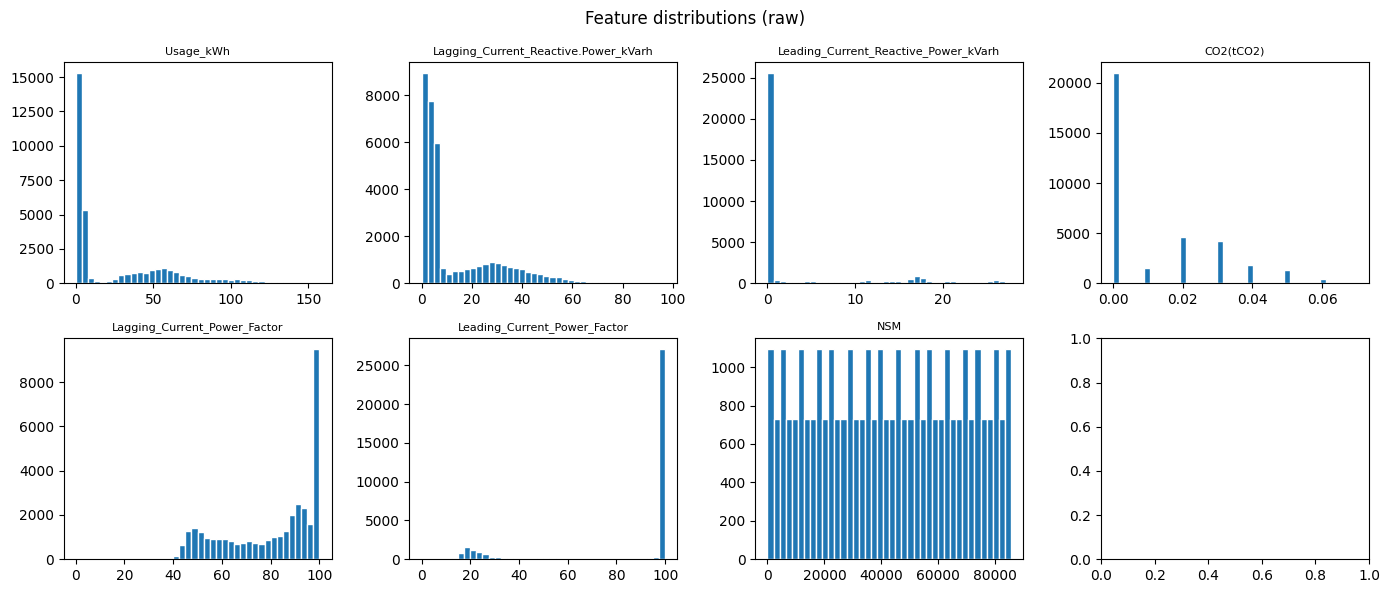

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, col in zip(axes.ravel(), num_cols):
    ax.hist(df[col], bins=40, edgecolor="white")
    ax.set_title(col, fontsize=8)
plt.suptitle("Feature distributions (raw)")
plt.tight_layout()
plt.show()

**What we notice:**
- `Leading_Current_Reactive_Power_kVarh` — lots of zeros (~67%)
- `CO2(tCO2)` — mostly zero (~60%)
- `Usage_kWh` — right-skewed (few high consumption spikes)

Zeros alone don't mean drop — we check correlation next.

## Correlation with target


In [ ]:
corr_target = df[num_cols].corr()[TARGET].drop(TARGET).sort_values(ascending=False)
print("Correlation with Usage_kWh:")
print(corr_target.round(4))

Correlation with Usage_kWh:
CO2(tCO2)                               0.9882
Lagging_Current_Reactive.Power_kVarh    0.8961
Lagging_Current_Power_Factor            0.3860
Leading_Current_Power_Factor            0.3536
NSM                                     0.2346
Leading_Current_Reactive_Power_kVarh   -0.3249
Name: Usage_kWh, dtype: float64


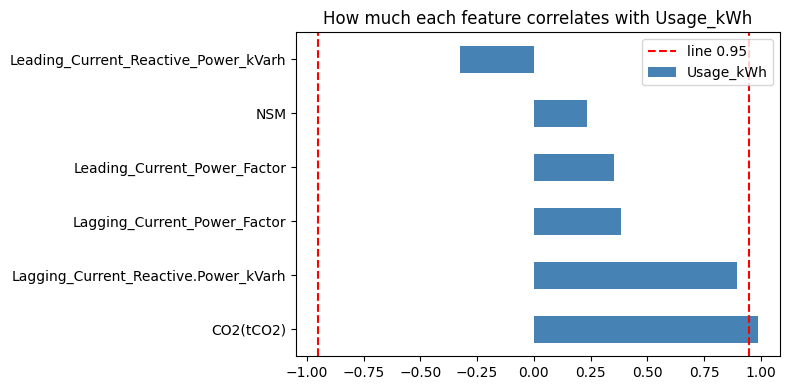

In [13]:
plt.figure(figsize=(8, 4))
corr_target.plot(kind="barh", color="steelblue")
plt.axvline(0.95, color="red", linestyle="--", label="line 0.95")
plt.axvline(-0.95, color="red", linestyle="--")
plt.title("How much each feature correlates with Usage_kWh")
plt.legend()
plt.tight_layout()
plt.show()

most of the time CO2 measure using the usage kwh and other factores

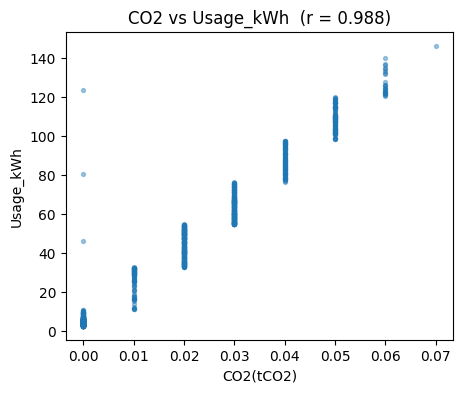

In [15]:
# Visual proof — CO2 almost tracks Usage_kWh
sample = df.sample(2000, random_state=42)
plt.figure(figsize=(5, 4))
plt.scatter(sample["CO2(tCO2)"], sample[TARGET], s=8, alpha=0.4)
plt.xlabel("CO2(tCO2)")
plt.ylabel("Usage_kWh")
plt.title(f"CO2 vs Usage_kWh  (r = {corr_target['CO2(tCO2)']:.3f})")
plt.show()

**Our conclusion from Part 3:**
- `CO2(tCO2)` has **r ≈ 0.99** with target → CO2 is *calculated from* energy use, not an independent sensor.
- Using it as input = **target leakage** (model looks accurate but learns nothing useful).
- `Lagging_Current_Reactive.Power_kVarh` has high r (~0.90) but it is a real electrical measurement — we **keep** it.
- We will **drop CO2**.

## Feature vs feature (redundant inputs)

Two inputs that say the same thing confuse the model.

NSM vs hour correlation: 0.9992


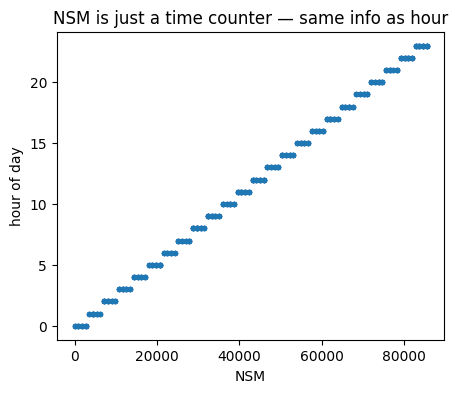

In [16]:
df["hour"] = df["date"].dt.hour

print("NSM vs hour correlation:", round(df["NSM"].corr(df["hour"]), 4))

sample = df.sample(2000, random_state=42)
plt.figure(figsize=(5, 4))
plt.scatter(sample["NSM"], sample["hour"], s=8, alpha=0.4)
plt.xlabel("NSM")
plt.ylabel("hour of day")
plt.title("NSM is just a time counter — same info as hour")
plt.show()

Leading reactive vs Leading power factor: -0.944


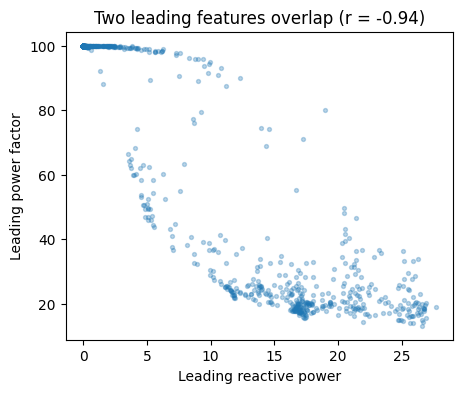

In [17]:
r_lr_lpf = df["Leading_Current_Reactive_Power_kVarh"].corr(df["Leading_Current_Power_Factor"])
print("Leading reactive vs Leading power factor:", round(r_lr_lpf, 4))

plt.figure(figsize=(5, 4))
plt.scatter(sample["Leading_Current_Reactive_Power_kVarh"], sample["Leading_Current_Power_Factor"], s=8, alpha=0.3)
plt.xlabel("Leading reactive power")
plt.ylabel("Leading power factor")
plt.title(f"Two leading features overlap (r = {r_lr_lpf:.2f})")
plt.show()

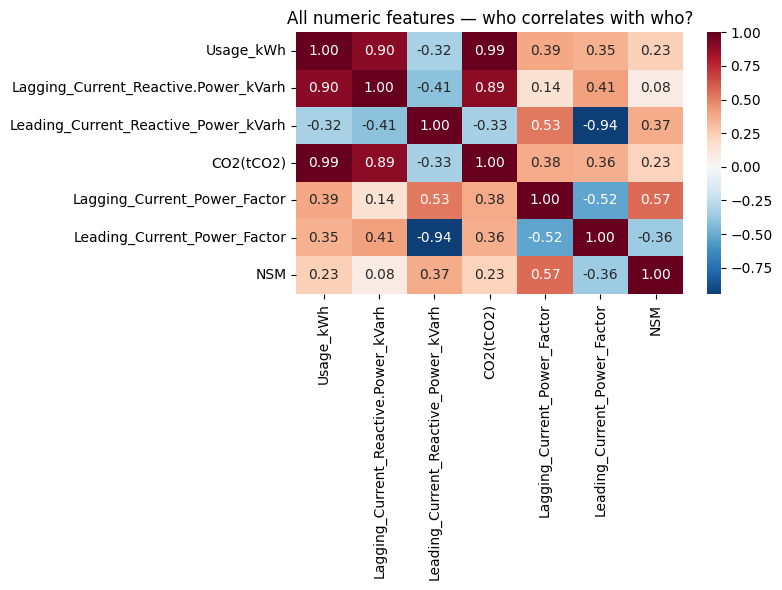

In [18]:
# Full input correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("All numeric features — who correlates with who?")
plt.tight_layout()
plt.show()

**Our conclusion from Part 4:**
- `NSM` ↔ `hour` has **r ≈ 0.999** → NSM is a 15-minute step counter, not new information. **Drop NSM**, add proper time features later.
- `Leading_Current_Reactive_Power_kVarh` ↔ `Leading_Current_Power_Factor` **r ≈ -0.94** and 67% zeros → **drop Leading reactive**.
- `WeekStatus` vs `Day_of_week` — we check quickly:

In [ ]:
ws = pd.Categorical(df["WeekStatus"]).codes
dw = pd.Categorical(df["Day_of_week"]).codes
print("WeekStatus vs Day_of_week correlation:", round(np.corrcoef(ws, dw)[0, 1], 4))

WeekStatus vs Day_of_week correlation: -0.1561


## Final feature decision (from our analysis above)

| Feature | Why |
|---------|-----|
| DROP `CO2(tCO2)` | r=0.99 with target — leakage |
| DROP `Leading_Current_Reactive_Power_kVarh` | 67% zeros + redundant with Leading PF |
| DROP `NSM` | |
| ADD `hour_sin`, `hour_cos` | replace NSM with smooth cyclical time |

In [ ]:
DROP = ["CO2(tCO2)", "Leading_Current_Reactive_Power_kVarh", "NSM"]
CAT_COLS = ["WeekStatus", "Day_of_week", "Load_Type"]

clean = df.drop(columns=DROP + ["hour"])  # hour was only for analysis

# cyclical hour instead of NSM
h = clean["date"].dt.hour + clean["date"].dt.minute / 60
clean["hour_sin"] = np.sin(2 * np.pi * h / 24)
clean["hour_cos"] = np.cos(2 * np.pi * h / 24)

# encode categories to numbers
for col in CAT_COLS:
    clean[col] = OrdinalEncoder().fit_transform(clean[[col]].astype(str))

feature_cols = [c for c in clean.columns if c != "date"]
# target first (needed for LSTM sliding windows)
feature_cols = [TARGET] + [c for c in feature_cols if c != TARGET]

print("Final features:", feature_cols)

Final features: ['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'WeekStatus', 'Day_of_week', 'Load_Type', 'hour_sin', 'hour_cos']


In [22]:
# Check we fixed leakage — no input should have |r| > 0.95 with target now
check = clean[feature_cols].corr()[TARGET].drop(TARGET)
print("Correlations after cleaning:")
print(check.round(4))
print("\nMax |r|:", round(check.abs().max(), 4), "→ OK if below 0.95")

Correlations after cleaning:
Lagging_Current_Reactive.Power_kVarh    0.8961
Lagging_Current_Power_Factor            0.3860
Leading_Current_Power_Factor            0.3536
WeekStatus                             -0.2955
Day_of_week                             0.0399
Load_Type                               0.4441
hour_sin                               -0.3053
hour_cos                               -0.4505
Name: Usage_kWh, dtype: float64

Max |r|: 0.8961 → OK if below 0.95


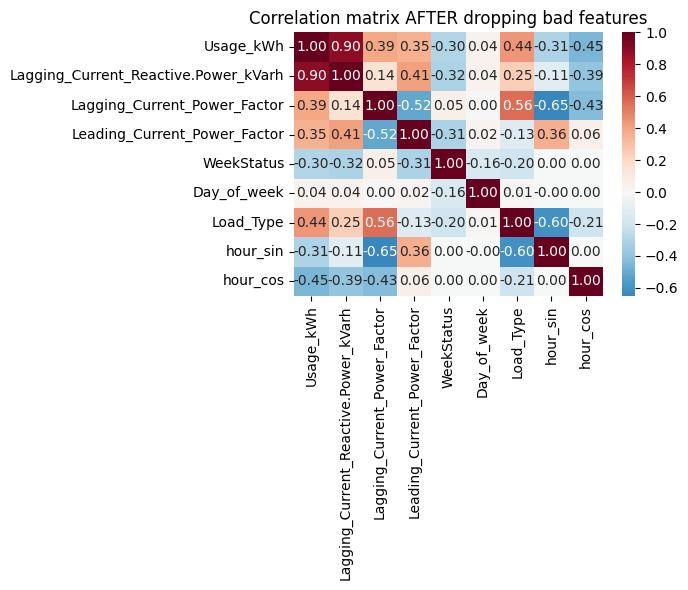

In [23]:
plt.figure(figsize=(7, 6))
sns.heatmap(clean[feature_cols].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Correlation matrix AFTER dropping bad features")
plt.tight_layout()
plt.show()

## Part 6 — Scale & save (15min + hourly)

- Split by **time** (first 82% train, last 18% test)
- `MinMaxScaler` fit on **train only**, then transform both
- Hourly track = resample to 1 hour (mean for numbers, first for categories)

In [25]:
# 15-minute data (native resolution)
save_preprocessed(clean, SAVE_15MIN)

Saved /content/drive/MyDrive/Shared-Colab-Storage/agent-final/outputs/preprocess/15min
  rows=35040, train=28732, test=6308, features=9


In [26]:
# Hourly — resample then save
hourly = clean.set_index("date").resample("h").agg({
    TARGET: "mean",
    "Lagging_Current_Reactive.Power_kVarh": "mean",
    "Lagging_Current_Power_Factor": "mean",
    "Leading_Current_Power_Factor": "mean",
    "hour_sin": "mean",
    "hour_cos": "mean",
    "WeekStatus": "first",
    "Day_of_week": "first",
    "Load_Type": "first",
}).reset_index()

print("15min rows:", len(clean), "→ hourly rows:", len(hourly))
save_preprocessed(hourly, SAVE_HOURLY)

15min rows: 35040 → hourly rows: 8760
Saved /content/drive/MyDrive/Shared-Colab-Storage/agent-final/outputs/preprocess/hourly
  rows=8760, train=7183, test=1577, features=9


In [27]:
# quick look at saved 15min data
saved = pd.read_csv(os.path.join(SAVE_15MIN, "data.csv"))
print(saved.head())
print("shape:", saved.shape)

   Usage_kWh  Lagging_Current_Reactive.Power_kVarh  \
0   0.006437                              0.035703   
1   0.004778                              0.030441   
2   0.010286                              0.046022   
3   0.005243                              0.033846   
4   0.005707                              0.036735   

   Lagging_Current_Power_Factor  Leading_Current_Power_Factor  WeekStatus  \
0                      0.529020                           1.0         0.0   
1                      0.575167                           1.0         0.0   
2                      0.473042                           1.0         0.0   
3                      0.528703                           1.0         0.0   
4                      0.493974                           1.0         0.0   

   Day_of_week  Load_Type  hour_sin  hour_cos  
0     0.166667        0.0  0.500000  1.000000  
1     0.166667        0.0  0.532702  0.998929  
2     0.166667        0.0  0.565263  0.995722  
3     0.166667      

## Done

You now have:
- `outputs/preprocess/15min/data.csv` + `scaler.pkl`
- `outputs/preprocess/hourly/data.csv` + `scaler.pkl`

Use these in the **training notebook** next.